# Evaluation 4: Prompt 8 - second run
```py
f"""
You are a writing assistant system for medical reports at the university hospital of the RWTH Aachen.

At the hospital medical reports are split into the following 5 sections:
1. Kinische Angaben
2. Fragestellung
3. Methodik
4. Befund
5. Beurteilung

Your Job is to correct the Befund section only, you should correct the Befund for grammar, spelling, and other syntax mistakes but you should also attempt to improve coherence and change the tone to bemore confident, you should try to keep the Befund structure and sentence order the same if possible.

Most crucially above all you are not allowed to change the semantics or meaning of the text nor are you allowed to add new information or omit information, this is of paramount importance as a badlywritten report is always better than one with incorrect information.

Lastly your response should only consist of the corrected Befund and nothing else, do not include formatting and don't provide explanations.

The following are the other available sections which you can use as context to help you with this task:
Klinische Angaben:
{report['klinische_angaben']}
Fragestellung:
{report['fragestellung']}
Methodik:
{report['methodik']}
Beurteilung:
{report['beurteilung']}
and here is the Befund section you are supposed to correct:
{report['befund']}
"""
```

In [1]:
# Imports
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker

In [2]:
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from evaluation_tool import duration_t_s_box_plot, multi_histogram, multi_bar_graph, multi_bar_model_graph, semantic_box_plot, violin_plot

In [3]:
prompt = "prompt8-2"
gt_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

In [4]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [5]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [6]:
# Evaluations Unique IDs
unique_ids_gt = [
    "gtb.45af4a46-d258-4251-b734-d407602299bd", #Base GT
]

unique_ids_medium = [
    "g2m-7-8.a6c6a962-f5a5-409c-adca-8f8dbd477a40", #gemma2:9b
    "l3m-1-8.5e2c9de7-1e8d-4231-8dab-11ca77281958", #llama3:8b
    "l31m-3-8.71347197-38b4-46ea-aa5e-986e91fe1eac", #llama3.1:8b
    "mm-9-8.49d754d3-7314-421d-a3db-3466995ac93a", #mistral-nemo:12b
]

In [7]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [8]:
def load_evaluations(unique_ids):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [9]:
res = load_evaluations(unique_ids_medium)

### Duration Metrics

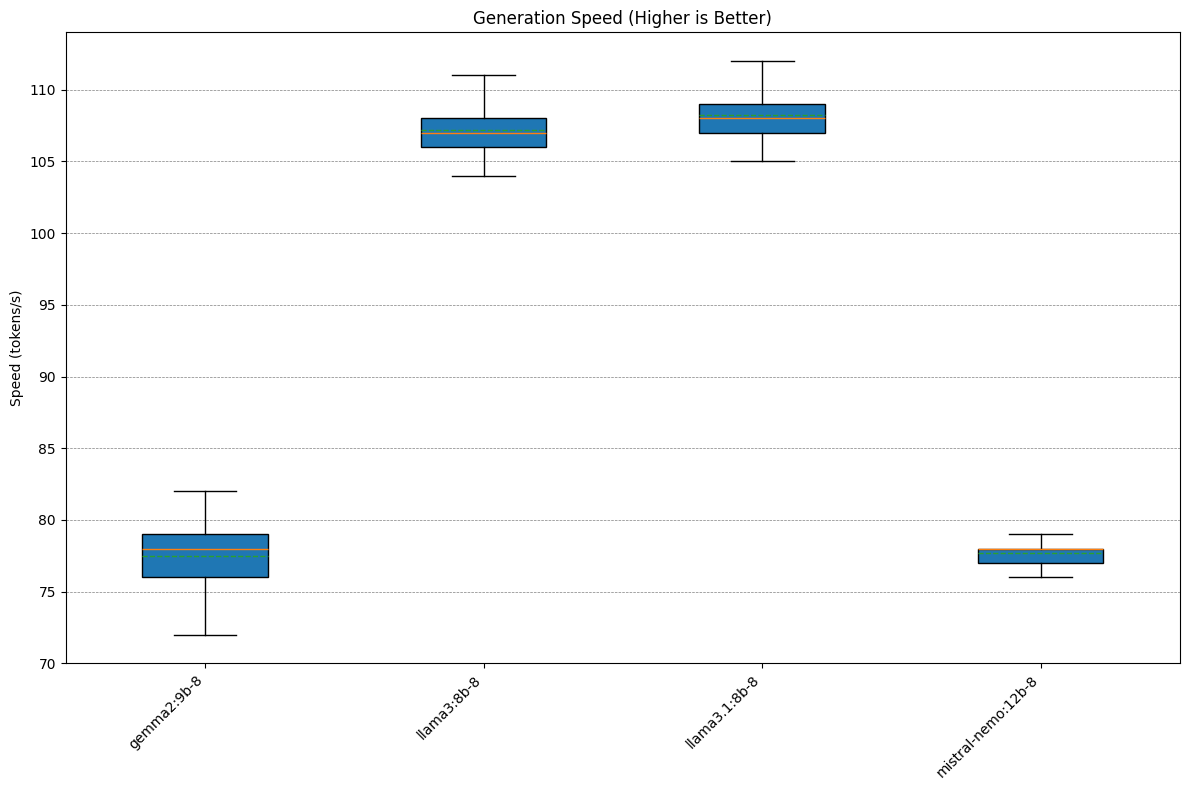

In [10]:
fig, ax = duration_t_s_box_plot(res)

### Difference Metrics

#### SM-Ratio

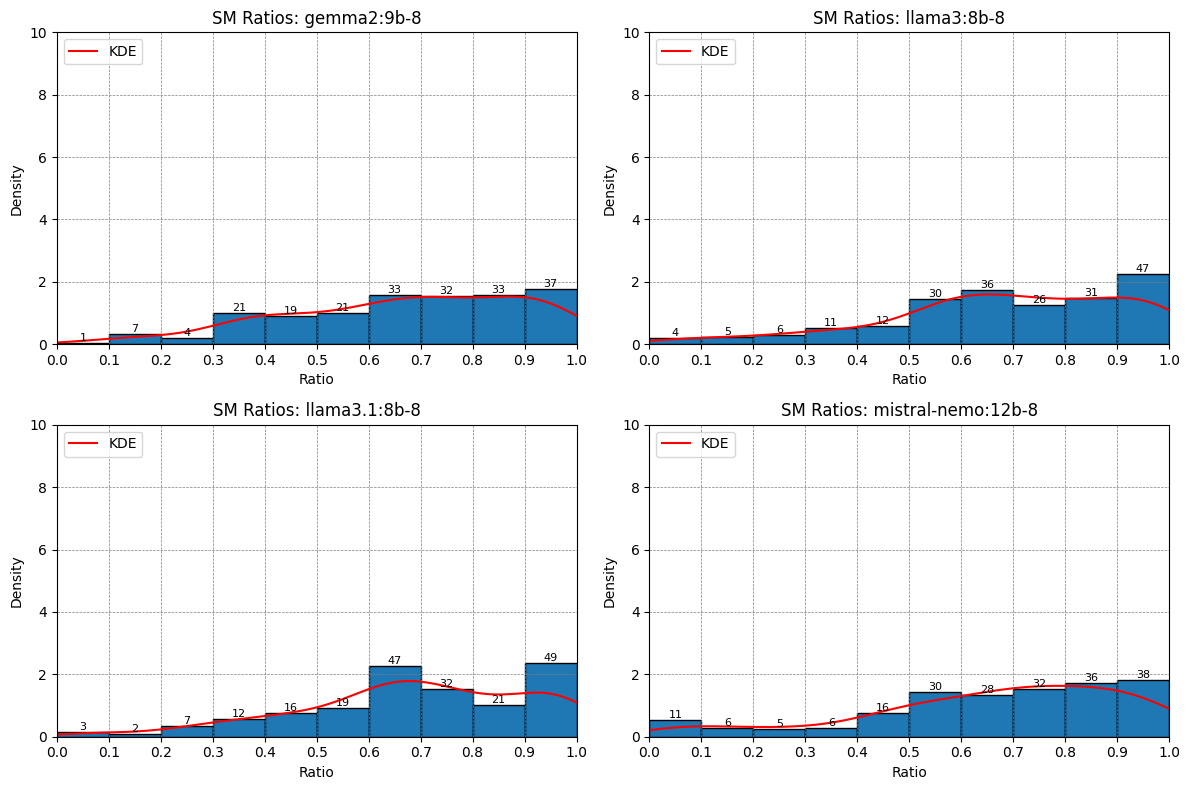

In [11]:
fig, axs = multi_histogram(res, "sm_similarity_ratios", "SM Ratios")

#### Levenshtein Distance Ratios

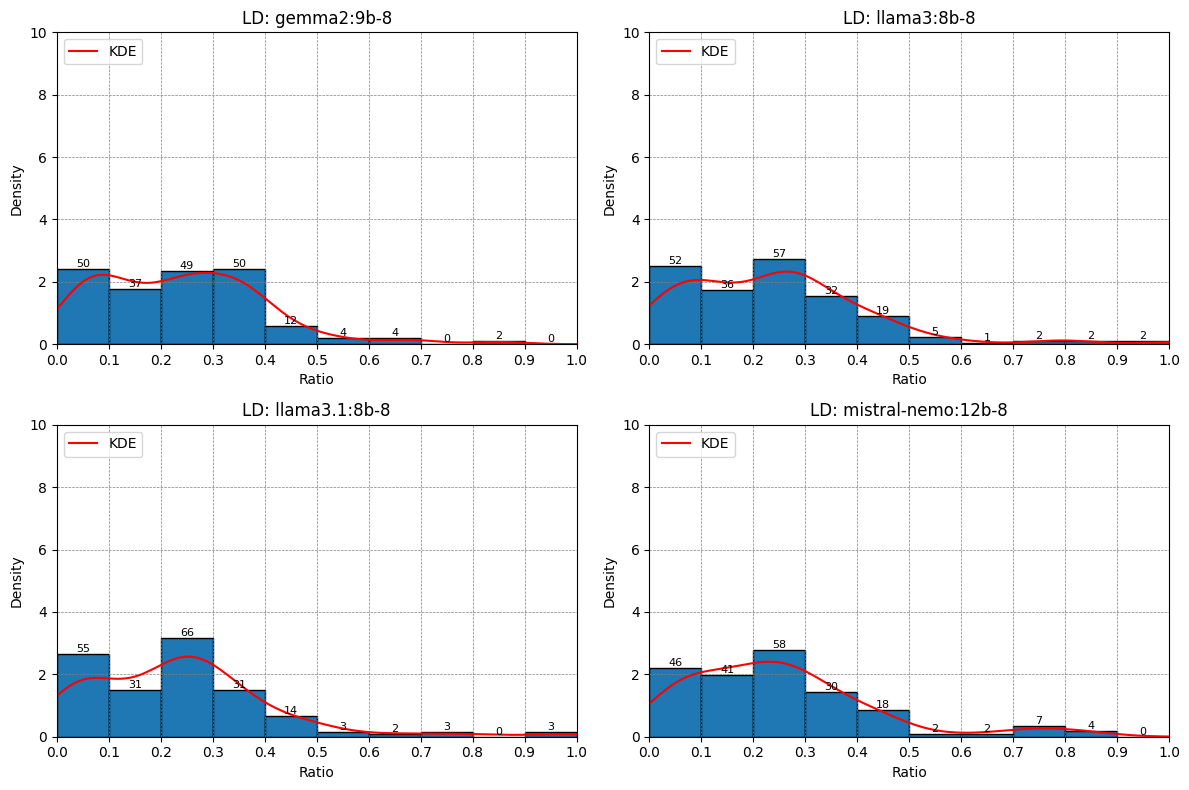

In [12]:
fig, axs = multi_histogram(res, "levenshtein_distance_ratios", "LD")

### LanguageTool Metrics

#### Spell Check

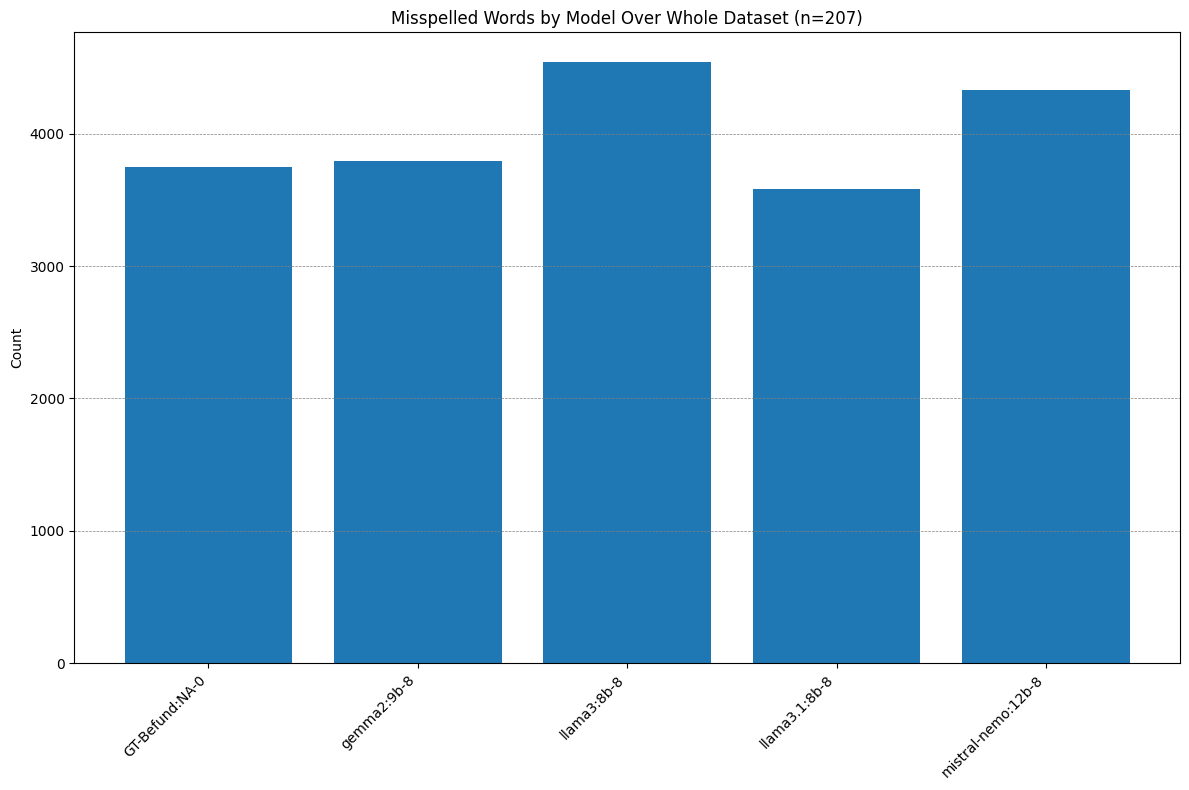

In [13]:
fig, ax = multi_bar_graph(gt_res + res, "misspelled", "Misspelled Words by Model Over Whole Dataset (n=207)")

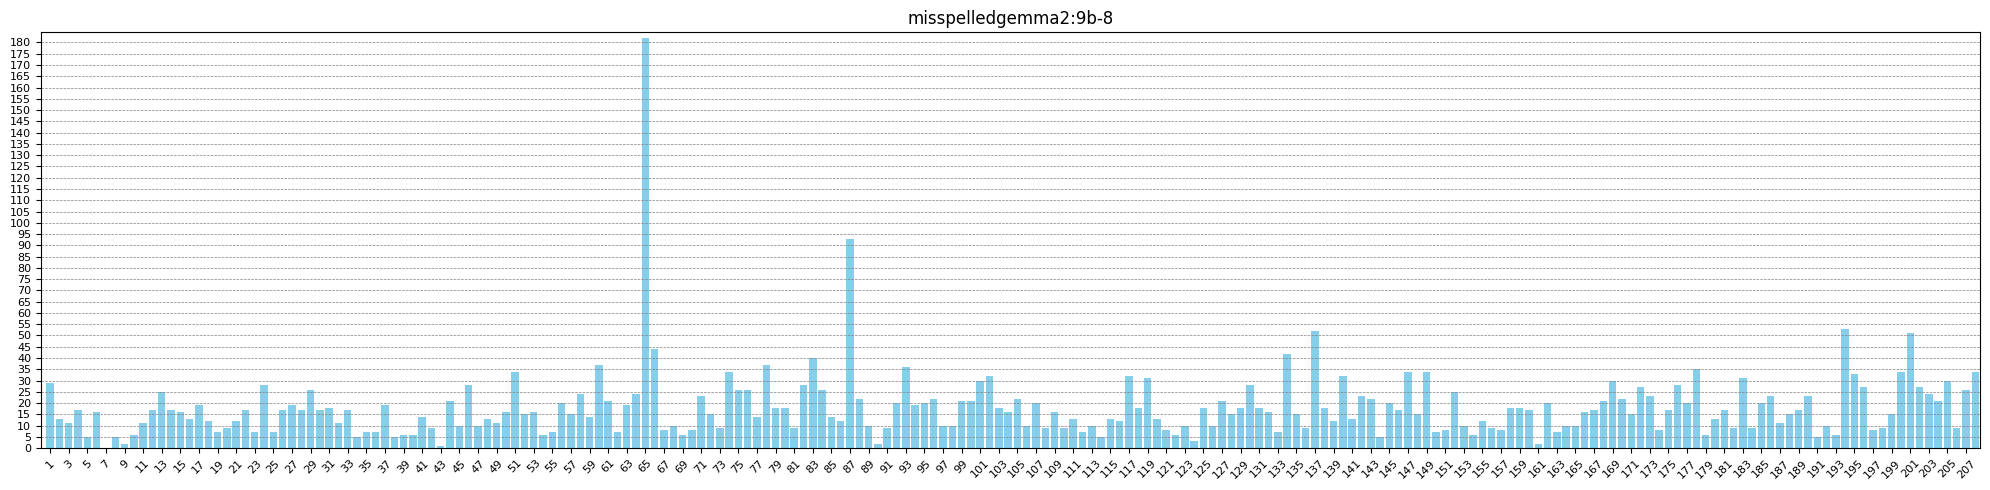

In [14]:
fig, ax = multi_bar_model_graph(res[0], "misspelled", 5)

#### Grammar Check

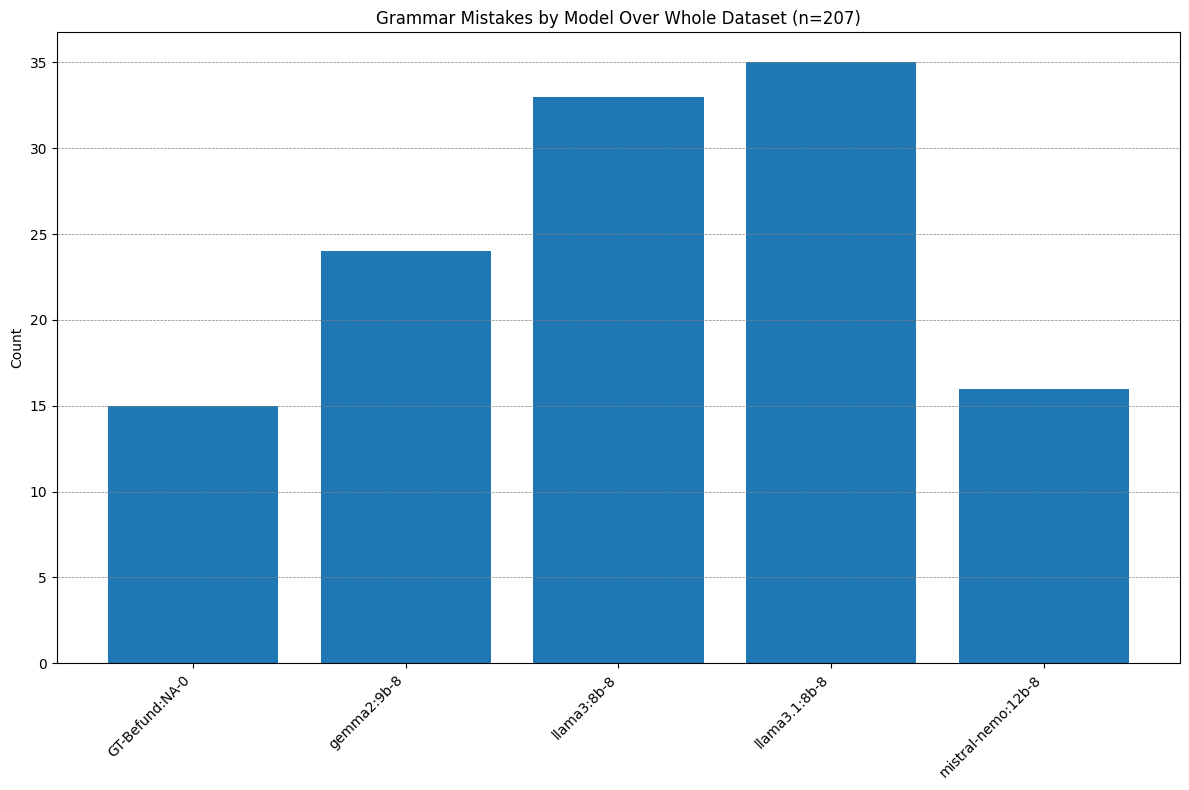

In [15]:
fig,ax = multi_bar_graph(gt_res + res, "grammer", "Grammar Mistakes by Model Over Whole Dataset (n=207)")

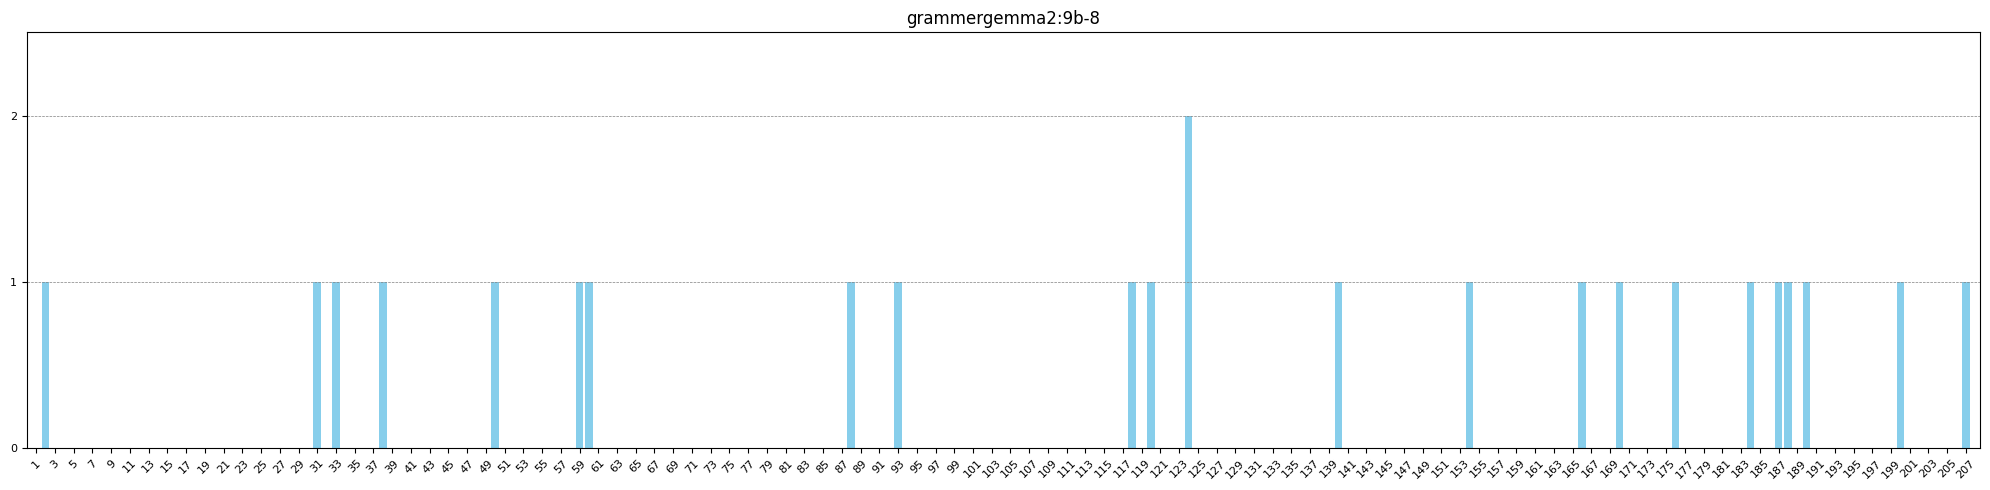

In [16]:
fig, ax = multi_bar_model_graph(res[0], "grammer", 1)

### Semantics Metrics

### Box Plot

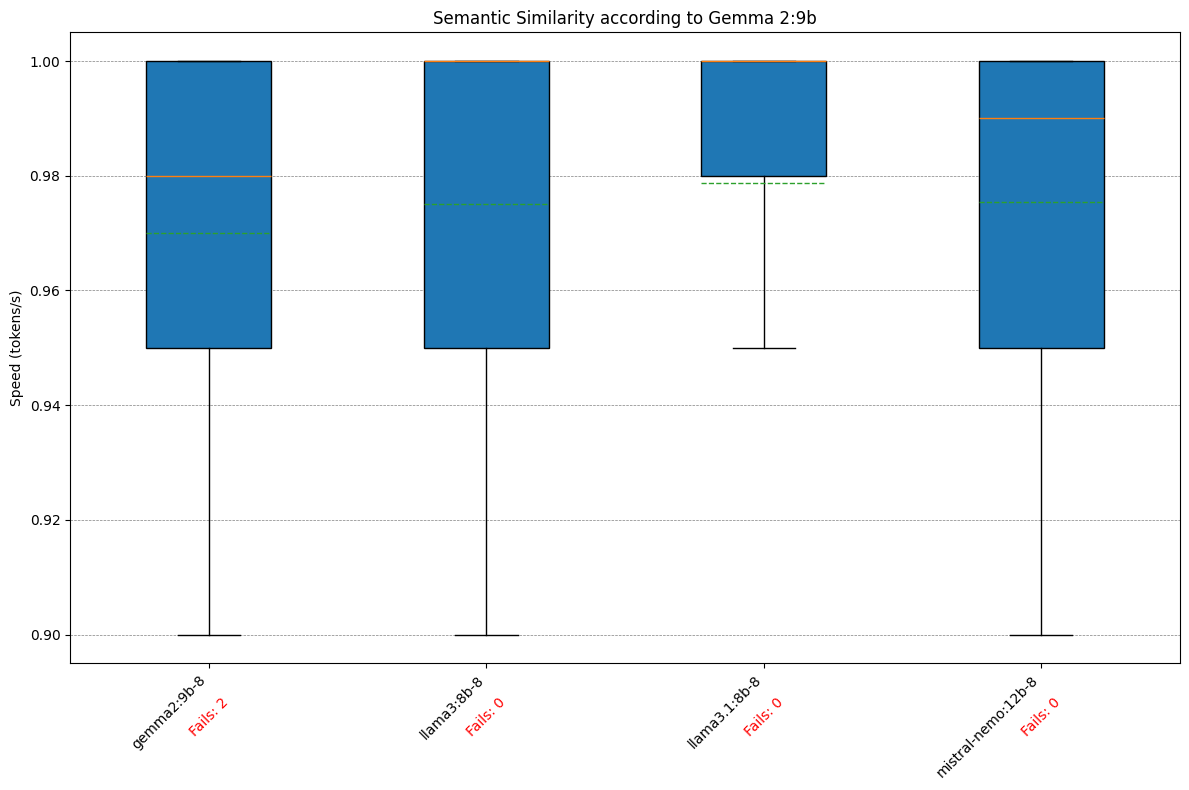

In [17]:
fig, ax = semantic_box_plot(res)

### Violin Plot

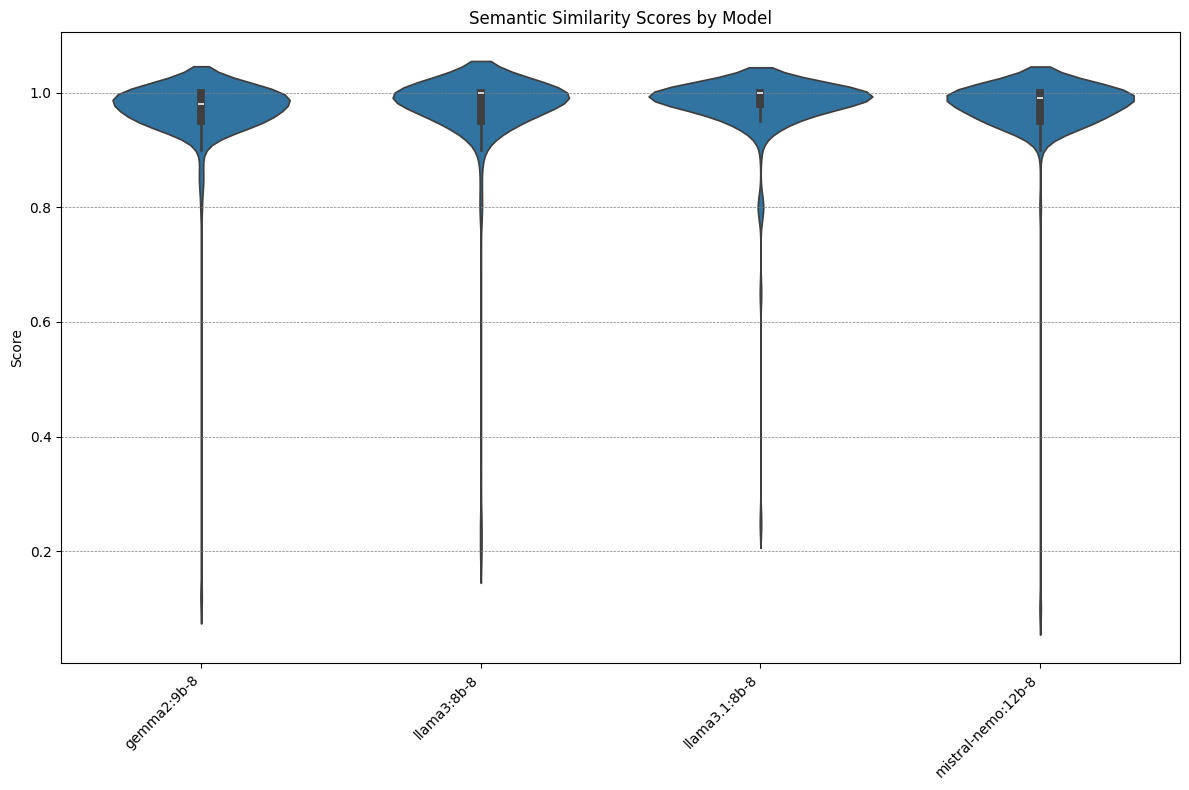

In [18]:
fig, ax = violin_plot(res)

In [19]:
def ratings_grouped_bar_chart(res, metric="llm_ratings"):
    "show a grouped bar chart of the semantic similarity ratings of the models"
    number_of_models = len(res)
    ratings_range = range(1, 6)
    data = []
    labels = []

    for i in range(number_of_models):
        llm_scores = res[i]["metrics"]["semantic_metrics"][metric]
        valid_scores = [score for score in llm_scores if score != -1]
        freq = [valid_scores.count(rating) for rating in ratings_range]
        data.append(freq)
        labels.append(f'{res[i]["model"]["name"]}:{res[i]["model"]["size"]}-{res[i]["prompt"]["id"]}')

    fig, ax = plt.subplots(figsize=(12, 8))

    bar_width = 0.15
    indices = np.arange(len(ratings_range))

    for i, freq in enumerate(data):
        ax.bar(indices + i * bar_width, freq, bar_width, label=labels[i])

    ax.set_title("Semantic Similarity Ratings")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Frequency")
    ax.set_xticks(indices + bar_width * (number_of_models - 1) / 2)
    ax.set_xticklabels(ratings_range)
    ax.legend()

    plt.xticks(rotation=45, ha="right")
    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")

    fig.tight_layout()
    return fig, ax

In [20]:
fig, ax = ratings_grouped_bar_chart(res)

KeyError: 'llm_ratings'